---
date: 2026-09-30 16:30
author: Jannik Schmöle
---

Example

In [1]:
%matplotlib widget

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from ipyfilechooser import FileChooser

from finapres_novascope_reader import (
	NOVASCOPE_TYPES,
	BloodPressure,
	average_bp,
	load_finapres,
	marker_arm_cuff_bp,
	marker_braCal_bp,
	plot_markers,
)

## Select the "{YYYY-MM-DD_HH.mm.ss} (csv) Raw" folder containing the CSVs from Finapres Novascope
fc = FileChooser()
display(fc)

FileChooser(path='/home/jannled/Dokumente/workspace/csv_parser_for_novascope', filename='', title='', show_hid…

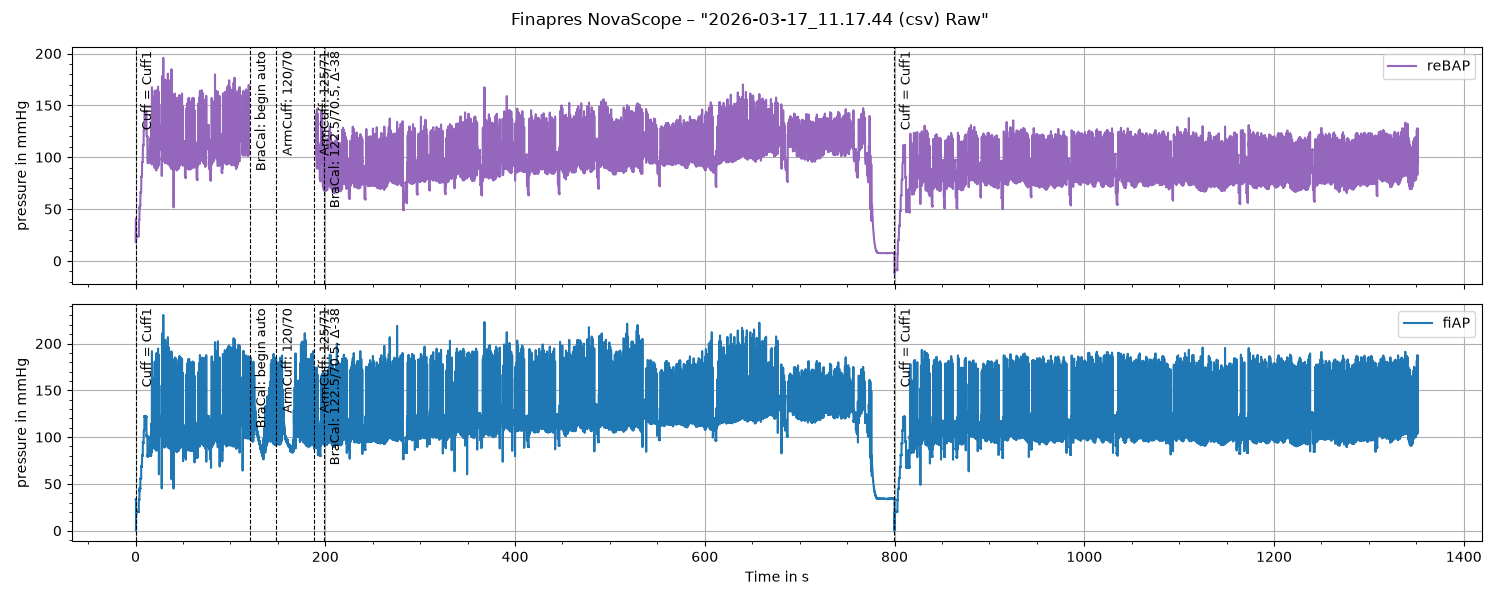

In [2]:
assert fc.selected is not None, 'Please select the exported folder containing the csv files before continuing'

dataset_name = Path(fc.selected).name

data: dict[NOVASCOPE_TYPES, pd.Series] = dict(
	load_finapres(
		fc.selected,
		whitelist=['reBAP', 'Markers', 'fiAP']
	)
)

fig, ax = plt.subplots(
	nrows=2,
	figsize=(15, 6),
	sharex=True
)

ax[0].plot(data['reBAP'].index.total_seconds(), data['reBAP'], label='reBAP', color='tab:purple')
ax[0].set_ylabel('pressure in mmHg')

ax[1].plot(data['fiAP'].index.total_seconds(), data['fiAP'], label='fiAP')
#ax[1].plot(data['fiAPLvl'].index, data['fiAPLvl'], label='fiAPLvl (mmHg)')
ax[1].set_ylabel('pressure in mmHg')

for a in ax:
	plot_markers(data['Markers'], a)
	a.grid()
	a.minorticks_on()
	a.legend(loc='upper right')

ax[-1].set_xlabel('Time in s')

fig.suptitle(f'Finapres NovaScope \u2013 "{dataset_name}"')
fig.tight_layout()

In [3]:
pressures: list[BloodPressure] = []

for marker in data['Markers']:
	assert isinstance(marker, str)

	# Begin of Arm Calibration
	if marker.startswith('BraCal: begin auto'):
		pressures = []

	# Value of Arm Calibration
	if marker.startswith('ArmCuff:'):
		pressure = marker_arm_cuff_bp(marker)
		print(f'"{dataset_name}": ArmCuff {pressure}')

		if pressure is not None:
			pressures.append(pressure)
	
	if marker.startswith('BraCal:') and '/' in marker:
		pressure, delta = marker_braCal_bp(marker)
		print(f'"{dataset_name}": BraCal {pressure}, Δ{delta}')

		print(average_bp(pressures))
		pressures = []

df_meta = pd.DataFrame([data['reBAP'].attrs])
df_meta

"2026-03-17_11.17.44 (csv) Raw": ArmCuff BloodPressure(sys=120.0, dia=70.0)
"2026-03-17_11.17.44 (csv) Raw": ArmCuff BloodPressure(sys=125.0, dia=71.0)
"2026-03-17_11.17.44 (csv) Raw": BraCal BloodPressure(sys=122.5, dia=70.5), Δ-38
BloodPressure(sys=122.5, dia=70.5)


,Measurement,Reference,Age(yrs),Height(cm),Weight(kg),Gender,FlowCorrection(%),Procedure,Application,MeasurementStart,Patient,Physician
0,2026-03-17_11.17.44,NaN,25,-1,-1,Male,100,NaN,NovaScope,2026-03-17_12:18:00.933,Jannik,REDACTED
